<a href="https://colab.research.google.com/github/AngeNana23/Assignment-10/blob/main/Assignment10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://colab.research.google.com/drive/16VgF5ozNYf1mUBcwH8eki19hKuJI6QOd?usp=sharing




https://github.com/AngeNana23/Assignment-10/blob/main/Assignment10.ipynb

#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


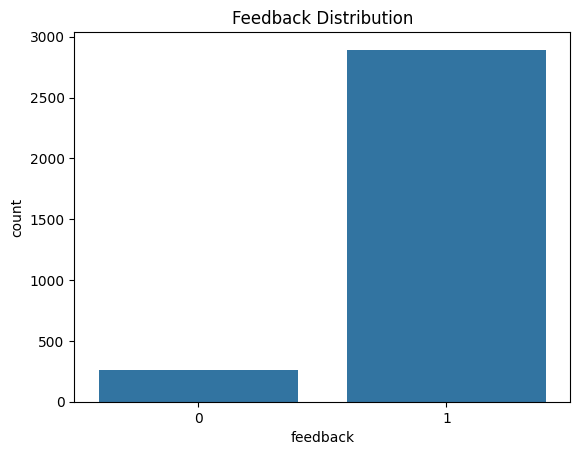

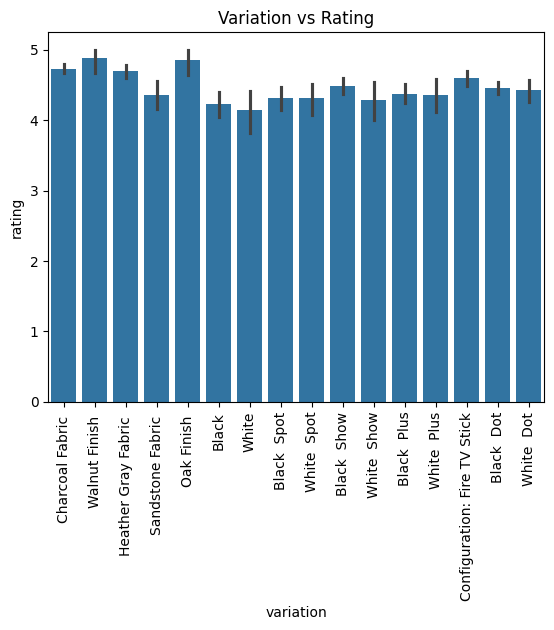

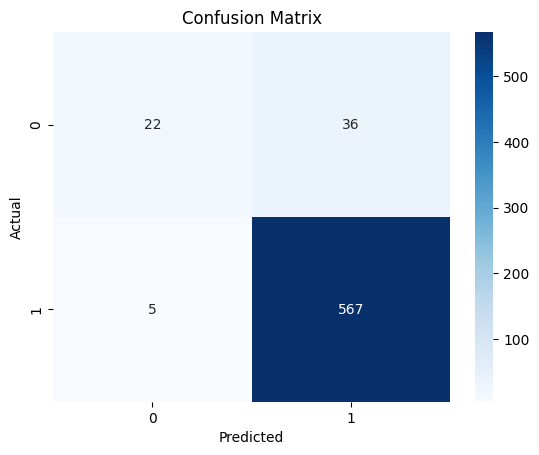

              precision    recall  f1-score   support

           0       0.81      0.38      0.52        58
           1       0.94      0.99      0.97       572

    accuracy                           0.93       630
   macro avg       0.88      0.69      0.74       630
weighted avg       0.93      0.93      0.92       630



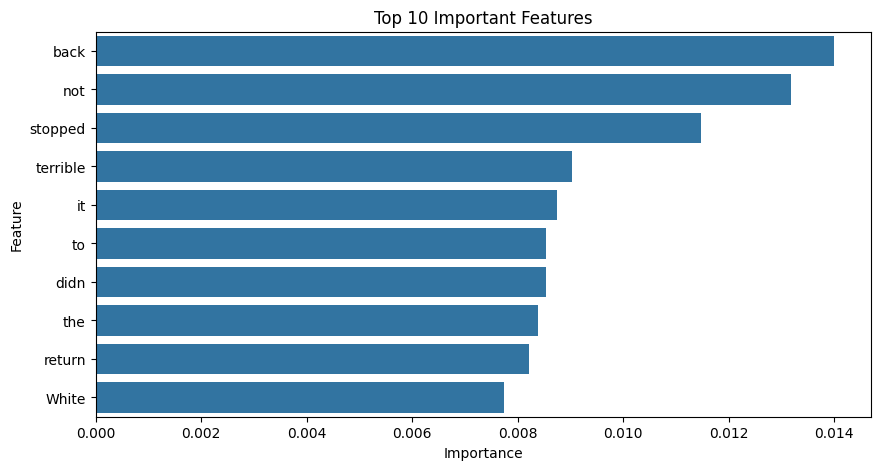

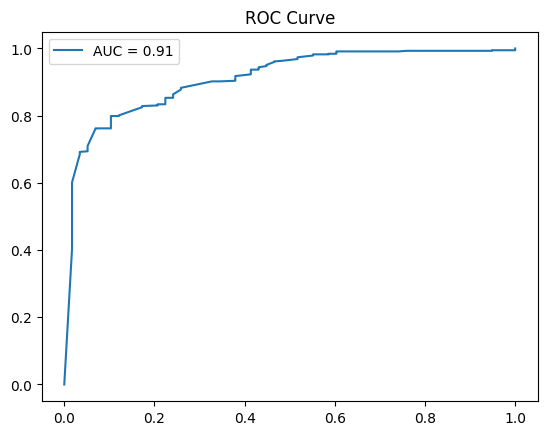

Positive


In [43]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest

# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive

df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')


# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

sns.countplot(x='feedback', data=df)
plt.title("Feedback Distribution")
plt.show()


# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

sns.barplot(x='variation', y='rating', data=df)
plt.xticks(rotation=90)
plt.title("Variation vs Rating")
plt.show()


# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

df = df.drop(['date', 'rating'], axis=1)


# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

variation_encoded = pd.get_dummies(df['variation'], drop_first=True)
df = pd.concat([df, variation_encoded], axis=1)
df = df.drop('variation', axis=1)


# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

df['verified_reviews'] = df['verified_reviews'].fillna('')

# ⚡ SPEED OPTIMIZATION: limit features
vectorizer = CountVectorizer(max_features=3000)
text_features = vectorizer.fit_transform(df['verified_reviews'])


# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

text_df = pd.DataFrame(
    text_features.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df = df.drop('verified_reviews', axis=1)
df = pd.concat([df.reset_index(drop=True), text_df.reset_index(drop=True)], axis=1)


# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

y = df['feedback']
X = df.drop('feedback', axis=1)


# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train the Random Forest model
# TODO: Create and train the Random Forest model

# ⚡ SPEED OPTIMIZATION: fewer trees
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


# Logistic Regression (FAST + LIGHT REQUIREMENT COVER)
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)


# Evaluate the model
# TODO: Generate predictions and create confusion matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)


# TODO: Plot confusion matrix

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# TODO: Print classification report

print(classification_report(y_test, y_pred))


# Feature Importance

importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 10 Important Features")
plt.show()


# ROC-AUC

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve")
plt.show()


# TODO: Make predictions on new data

def predict_sentiment(review_text):
    review_vector = vectorizer.transform([review_text]).toarray()

    review_df = pd.DataFrame(review_vector, columns=vectorizer.get_feature_names_out())

    missing_cols_in_review = set(X.columns) - set(review_df.columns)
    for c in missing_cols_in_review:
        review_df[c] = 0

    review_df = review_df[X.columns]

    prediction = model.predict(review_df)[0]

    return "Positive" if prediction == 1 else "Negative"


new_review = "I love my Alexa device! It's so helpful."
print(predict_sentiment(new_review))

In [44]:
print(predict_sentiment("I absolutely love this Alexa device"))
print(predict_sentiment("This product is terrible and useless"))

Positive
Negative
